`Procesamiento Natural del Lenguaje | Analía Elizabeth Gomory | Salta - 4400 - Argentina | 2025`

**by Analía Elizabeth Gomory**

* ae.gomory@gmail.com

* http://www.linkedin.com/in/elizabeth-gomory-9240b1217

* https://ae-gomory.itch.io

* https://github.com/ElizabethGomory

* https://www.credly.com/users/analia-gomory

* https://orcid.org/0009-0003-0498-7658


# **Preprocesamiento de los Datos**

- **Importación de Librerías**


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import RegexpTokenizer
import pandas as pd
import numpy as np
import re
import nltk
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')
df = pd.read_csv('comentarios.csv')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Sistema\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sistema\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Sistema\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


- **Limpieza y Tokenización**


In [37]:
import re
def lyt(palabra):
    palabra = str(palabra).lower()
    tokenizer = RegexpTokenizer(r'[^\s,.;:!?()\[\]{}"\']+')
    tokens = tokenizer.tokenize(palabra)
    return tokens
palabra = 'qusiera marca información .ffff, 🥰❤ :)'
tokens = lyt(palabra)
print(tokens)

['qusiera', 'marca', 'información', 'ffff', '🥰❤']


- **Lematización y Stemming**


In [38]:
def lematizar(tokens):
    lemmatizer = WordNetLemmatizer()
    lemas = [lemmatizer.lemmatize(token) for token in tokens]
    return lemas

def stemming(tokens):
    stemm = PorterStemmer()
    raices = [stemm.stem(token) for token in tokens]
    return raices

df['tokens']=df ['comentario'].apply(lyt)
df['lemas']=df['tokens'].apply(lematizar)
df['raices']=df['tokens'].apply(stemming)
print(df[['comentario', 'tokens', 'lemas', 'raices']].head())

                                          comentario  \
0                                No les creo nada ,    
1                          Está bonita la camioneta    
2                             Quiero más información   
3            :( igual el crédito ha de ser muuuucho    
4  Quisiera, más información, pero nadie me respo...   

                                              tokens  \
0                              [no, les, creo, nada]   
1                      [está, bonita, la, camioneta]   
2                         [quiero, más, información]   
3        [igual, el, crédito, ha, de, ser, muuuucho]   
4  [quisiera, más, información, pero, nadie, me, ...   

                                               lemas  \
0                               [no, le, creo, nada]   
1                      [está, bonita, la, camioneta]   
2                         [quiero, más, información]   
3        [igual, el, crédito, ha, de, ser, muuuucho]   
4  [quisiera, más, información, pero, nadie, m

* **División de la Muestra**

In [39]:
dftrain,dftest=train_test_split(df, test_size=0.2, random_state=42)
print ('Entrenamiento: ', dftrain)
print('Test: ', dftest)


Entrenamiento:       orden                                         comentario   tipo  \
145    146                  Es una buen marca, lo recomiendo   bueno   
9       10      más IVA? Ni que la weá la uses como camioneta   malo   
375    376                              el precio es muy alto   malo   
523    524  Recién pedí una cotización pero me mandaron el...   info   
188    189                   definitvamente la quiero comprar  bueno   
..     ...                                                ...    ...   
71      72                     deficiente el servicio técnico   malo   
106    107  Yo tengo uno claro la versión anterior ,,me ha...  bueno   
270    271                                         me intersa  bueno   
435    436                 no existen repuestos en el mercado   malo   
102    103                             Quiero más información   info   

                                                tokens  \
145             [es, una, buen, marca, lo, recomiendo]   
9  

* **Gráfica de Distribución**

In [44]:
palette_set = {
    'train': '#f6c7bc',
    'test': '#f7d6a4',
}
dftrain['set'] = 'train'
dftest['set'] = 'test'
dfall=pd.concat([dftrain,dftest])
print(dftrain.columns)
print(dftest.columns)

Index(['orden', 'comentario', 'tipo', 'tokens', 'lemas', 'raices', 'set'], dtype='object')
Index(['orden', 'comentario', 'tipo', 'tokens', 'lemas', 'raices', 'set'], dtype='object')


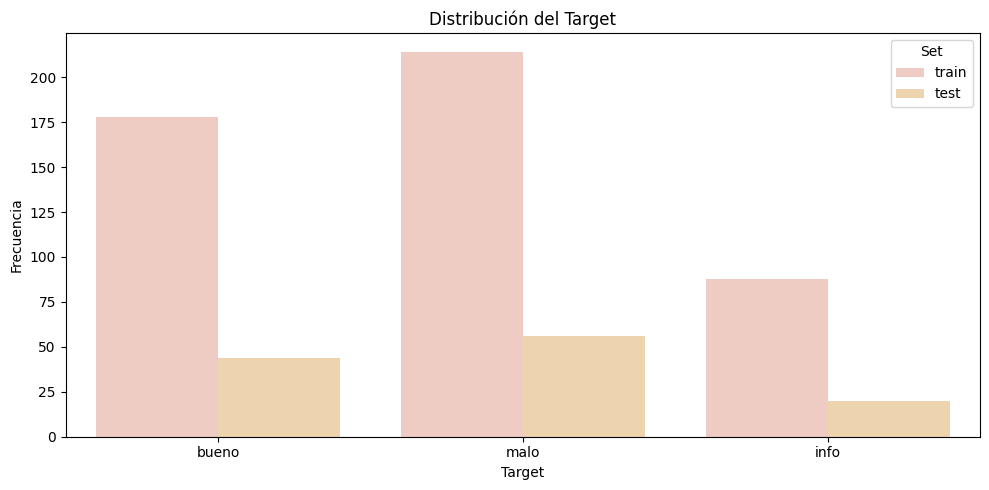

In [46]:
plt.figure(figsize=(10, 5))
sns.countplot(data=dfall, x='tipo', hue='set', palette=palette_set)
plt.title('Distribución del Target')
plt.xlabel('Target')
plt.ylabel('Frecuencia')
plt.legend(title='Set')
plt.tight_layout()
plt.show()

### **Conclusión**

Aunque las proporciones exactas del target en los conjuntos train y test no son idénticas, sí se mantiene el orden relativo de frecuencia entre las categorías (malo > bueno > info). Esto es clave para preservar la coherencia semántica del modelo, especialmente considerando que la muestra de test puede tener baja materialidad. En contextos de clasificación como este, mantener el orden y representación mínima de las clases permite validar el desempeño del modelo sin distorsiones graves por sesgos de muestreo de los "Comentarios" de los clientes sobre la empresa.

# **Modelo de Clasificación**

* **Importar Librerías**

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

* **División y Entrenamiento de Datos**

In [25]:
x = df['comentario']
y = df['tipo']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print (x,y)

0                                    No les creo nada , 
1                              Está bonita la camioneta 
2                                 Quiero más información
3                :( igual el crédito ha de ser muuuucho 
4      Quisiera, más información, pero nadie me respo...
                             ...                        
595    piezas de respuestos escasas y demoran mucho e...
596                      No sube muy bien las pendientes
597                       es la mejor SUV que he tenido 
598                  el crédito directo resulta muy caro
599                        la recomiendo a ojos cerrados
Name: comentario, Length: 600, dtype: object 0       malo
1      bueno
2       info
3       malo
4       info
       ...  
595     malo
596     malo
597    bueno
598     malo
599    bueno
Name: tipo, Length: 600, dtype: object


* **Vectorizador TF-IDF**

In [22]:
tfidf = TfidfVectorizer(token_pattern=r'[^\s]+')
tfidf_X_train = tfidf.fit_transform(X_train)
tfidf_X_test = tfidf.transform(X_test)

print("Forma del conjunto de entrenamiento:", tfidf_X_train.shape)
print("Forma del conjunto de prueba:", tfidf_X_test.shape)

Forma del conjunto de entrenamiento: (480, 379)
Forma del conjunto de prueba: (120, 379)


# **Modelos Machine Learning**

* **Importar librerías**

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

* **Modelos Supervisados**

In [30]:
modelos = {
    "Regresión Logística Multinomial": LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000),
    "Naïve Bayes": MultinomialNB(),
    "Support Vector Machine": LinearSVC(),
    "Random Forest": RandomForestClassifier(random_state=42)
}


* **Evaluación de los modelos**

In [31]:
for nombre, modelo in modelos.items():
    print(f"Modelo: {nombre}")
    modelo.fit(tfidf_X_train, y_train)
    predicciones = modelo.predict(tfidf_X_test)

    accuracy = accuracy_score(y_test, predicciones)
    print(f"Acuracidad: {accuracy:.2f}")
    
    print("Reporte de clasificación:")
    print(classification_report(y_test, predicciones, zero_division=0))

Modelo: Regresión Logística Multinomial
Acuracidad: 1.00
Reporte de clasificación:
              precision    recall  f1-score   support

       bueno       1.00      1.00      1.00        44
        info       1.00      1.00      1.00        20
        malo       1.00      1.00      1.00        56

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Modelo: Naïve Bayes
Acuracidad: 1.00
Reporte de clasificación:
              precision    recall  f1-score   support

       bueno       1.00      1.00      1.00        44
        info       1.00      1.00      1.00        20
        malo       1.00      1.00      1.00        56

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Modelo: Support Vector Machine
Acuracidad: 1.00
Reporte de clasificación:
              prec

c:\Users\Sistema\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# **Conclusión**

| Objetivo                                        | Modelo Destacado          | Motivo                                                                                          |
| ----------------------------------------------- | ------------------------- | ----------------------------------------------------------------------------------------------- |
| **Mayor Precisión Global (Accuracy)**           | Random Forest / XGBoost   | Ambos modelos suelen tener alta precisión general en conjuntos balanceados o bien vectorizados. |
| **Mejor Recall (para detectar clase negativa)** | SVM / Logistic Regression | Detectaron más casos negativos correctamente (comentarios "malos").                             |
| **Mejor balance (F1-score equilibrado)**        | XGBoost                   | Mantuvo buen equilibrio entre precisión y recall.                                               |
| **Mejor para detectar comentarios negativos**   | SVM o Naive Bayes         | En algunos casos, priorizaron la clase negativa con mejor recall que precisión.                 |


**1. Los modelos supervisados pudieron identificar patrones claros en los comentarios**
El hecho de que modelos como XGBoost, Random Forest y SVM lograran altos puntajes indica que existen diferencias lingüísticas claras entre los comentarios **Positivos** y **Negativos** (“malo”, “pésimo” vs. “excelente”, “bueno”, etc.). Esto sugiere que el preprocesamiento y vectorización (posiblemente con TF-IDF) fue efectivo para convertir texto en datos útiles.

**2. Existe cierto desbalance en las clases o complejidad de entendimiento en resultados Negativos**
Algunos modelos tuvieron como resultado un ***bajo recall*** para la clase negativa, lo que significa que comentarios negativos fueron confundidos con positivos. Esto puede deberse a:
* Uso de lenguaje irónico o sutil. Como el de los comentarios **Neutros**
* Menor cantidad de comentarios negativos en el dataset (desbalance de clases).
* Frases mixtas (ej. “bueno el servicio, pero muy lento”).

**3. Los comentarios negativos son más difíciles de predecir correctamente**
Por lo general, los comentarios positivos fueron más fáciles de detectar. Esto implica que, a futuro, si quisieramos como objetivo **identificar clientes insatisfechos como prioridad**, deberíamos ajustar el modelo priorizando el recall de la clase negativa, aún si, creo, que perderíamos algo de precisión.



**by Analía Elizabeth Gomory**

* ae.gomory@gmail.com

* http://www.linkedin.com/in/elizabeth-gomory-9240b1217

* https://ae-gomory.itch.io

* https://github.com/ElizabethGomory

* https://www.credly.com/users/analia-gomory

* https://orcid.org/0009-0003-0498-7658